# Foundation Model Experiments — MOMENT, TiReX & Chronos-2 for LSST

- **M1**: MOMENT zero-shot embeddings + sklearn classifier
- **M2**: MOMENT pre-computed features + trainable MLP head (encoder frozen)
- **M3**: MOMENT full end-to-end fine-tuning
- **M4**: TiReX zero-shot embeddings + sklearn classifier
- **M5**: TiReX pre-computed features + trainable MLP head (encoder frozen)
- **M6**: TiReX full end-to-end fine-tuning (infeasible — OOM)
- **M7**: Chronos-2 zero-shot embeddings + sklearn classifier
- **M8**: Chronos-2 pre-computed features + trainable MLP head (encoder frozen)

MOMENT (ICML 2024): general-purpose FM pre-trained via masked time-series modeling.
TiReX (NeurIPS 2025 workshop): xLSTM-based univariate forecasting FM.
Chronos-2 (Amazon, 2025): patch-based forecasting FM with native multivariate support.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from src.data_loader import (
    load_lsst_for_moment, load_lsst_for_sklearn,
    stratified_train_val_split, SEED,
)
from src.moment_pipeline import (
    extract_moment_embeddings,
    extract_moment_classification_features,
    train_classification_head,
    load_moment_for_classification,
    finetune_moment,
    predict_moment,
)
from src.tirex_pipeline import (
    extract_tirex_embeddings,
    load_tirex_for_classification,
    finetune_tirex,
    predict_tirex,
)
from src.chronos_pipeline import extract_chronos_embeddings
from src.metrics import evaluate, plot_confusion_matrix, results_table

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [4]:
# Load data
data_sk = load_lsst_for_sklearn()
data_m = load_lsst_for_moment(device="cpu")  # keep on CPU, move to GPU in batches

class_names = data_sk["class_names"]
n_classes = data_sk["n_classes"]
y_train = data_sk["y_train"]
y_test = data_sk["y_test"]

print(f"Classes: {n_classes}, Train: {data_m['X_train'].shape}, Test: {data_m['X_test'].shape}")

Classes: 14, Train: torch.Size([2459, 6, 512]), Test: torch.Size([2466, 6, 512])


## M1: Zero-shot MOMENT Embeddings + Classifier

Use `model.embed()` to get pooled representations, then train sklearn classifiers on top.

In [14]:
# Extract embeddings using MOMENT-1-small
MODEL_NAME = "AutonLab/MOMENT-1-small"

emb_train = extract_moment_embeddings(
    data_m["X_train"], data_m["mask_train"],
    model_name=MODEL_NAME, device=device,
)
emb_test = extract_moment_embeddings(
    data_m["X_test"], data_m["mask_test"],
    model_name=MODEL_NAME, device=device,
)
print(f"Embeddings — train: {emb_train.shape}, test: {emb_test.shape}")

Embeddings — train: (2459, 3072), test: (2466, 3072)


In [15]:
# Logistic Regression on MOMENT embeddings
lr_clf = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=SEED, C=1.0,
)
lr_clf.fit(emb_train, y_train)
y_pred_m1_lr = lr_clf.predict(emb_test)
metrics_m1_lr = evaluate(y_test, y_pred_m1_lr, class_names, "MOMENT ZS + LogReg")

# Random Forest on MOMENT embeddings
rf_clf = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=SEED,
)
rf_clf.fit(emb_train, y_train)
y_pred_m1_rf = rf_clf.predict(emb_test)
metrics_m1_rf = evaluate(y_test, y_pred_m1_rf, class_names, "MOMENT ZS + RF")

=== MOMENT ZS + LogReg ===
Accuracy:    0.5247
Weighted F1: 0.5381
Macro F1:    0.4262
              precision    recall  f1-score   support

          15       0.43      0.64      0.52       124
          16       0.89      0.84      0.87       270
          42       0.42      0.36      0.39       382
          52       0.10      0.17      0.12        63
          53       0.33      0.14      0.20         7
           6       0.43      0.34      0.38        35
          62       0.20      0.31      0.25       153
          64       0.08      0.12      0.10        24
          65       0.65      0.77      0.70       313
          67       0.11      0.24      0.15        68
          88       0.81      0.87      0.84       121
          90       0.70      0.44      0.54       777
          92       0.69      0.73      0.71        77
          95       0.18      0.23      0.20        52

    accuracy                           0.52      2466
   macro avg       0.43      0.44      0.43    

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

## M2: Pre-computed Features + Trainable MLP Head

The MOMENT encoder uses gradient checkpointing, which breaks gradient flow when
the encoder is frozen. Instead, we:
1. Pre-compute encoder features (one-time forward pass, no gradients needed)
2. Train a small MLP head on those features (fast, proper gradient flow)

This is equivalent to freezing the encoder but avoids the checkpointing bug.

In [20]:
# Pre-compute classification features from MOMENT encoder
feats_train = extract_moment_classification_features(
    data_m["X_train"], data_m["mask_train"],
    model_name=MODEL_NAME, device=device,
)
feats_test = extract_moment_classification_features(
    data_m["X_test"], data_m["mask_test"],
    model_name=MODEL_NAME, device=device,
)
print(f"Classification features — train: {feats_train.shape}, test: {feats_test.shape}")

Classification features — train: (2459, 3072), test: (2466, 3072)


In [21]:
# Stratified train/val split on pre-computed features
feats_tr, feats_val, y_tr, y_val = stratified_train_val_split(feats_train, y_train)
print(f"Train: {feats_tr.shape}, Val: {feats_val.shape}")

# Train MLP head
head_m2, history_m2 = train_classification_head(
    feats_tr, y_tr, feats_val, y_val,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=100, lr=1e-3, batch_size=128, patience=15,
    device=device,
)

Train: (1967, 3072), Val: (492, 3072)
Head trainable params: 790,286 (input_dim=3072)
Epoch 10/100 — train_loss=1.3101  val_loss=1.8355  val_wf1=0.2952
Epoch 20/100 — train_loss=0.9135  val_loss=1.8778  val_wf1=0.4394
Epoch 30/100 — train_loss=0.6953  val_loss=1.9853  val_wf1=0.3421
Epoch 40/100 — train_loss=0.5587  val_loss=2.2046  val_wf1=0.4206
Epoch 50/100 — train_loss=0.4553  val_loss=2.2670  val_wf1=0.4314
Epoch 60/100 — train_loss=0.3979  val_loss=2.4422  val_wf1=0.4584
Epoch 70/100 — train_loss=0.3623  val_loss=2.4411  val_wf1=0.4656
Epoch 80/100 — train_loss=0.3394  val_loss=2.5169  val_wf1=0.4711
Epoch 90/100 — train_loss=0.3409  val_loss=2.5292  val_wf1=0.4720
Early stopping at epoch 96


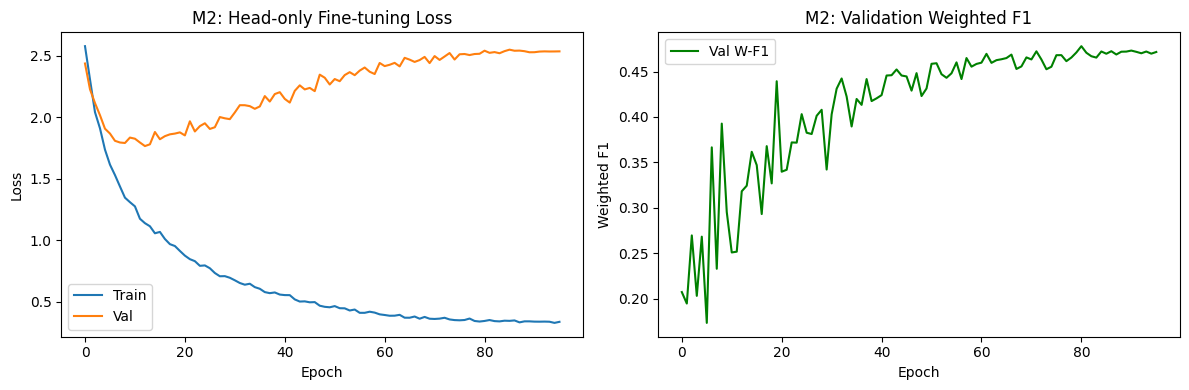

In [22]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m2["train_loss"], label="Train")
ax1.plot(history_m2["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M2: Head-only Fine-tuning Loss")
ax2.plot(history_m2["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M2: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [23]:
# Evaluate M2 on test set
feats_test_flat = feats_test.reshape(feats_test.shape[0], -1) if feats_test.ndim > 2 else feats_test
feats_test_t = torch.tensor(feats_test_flat, dtype=torch.float32, device=device)

head_m2.eval()
with torch.no_grad():
    y_pred_m2 = head_m2(feats_test_t).argmax(1).cpu().numpy()

metrics_m2 = evaluate(y_test, y_pred_m2, class_names, "MOMENT Head-FT (M2)")

=== MOMENT Head-FT (M2) ===
Accuracy:    0.4862
Weighted F1: 0.4917
Macro F1:    0.3443
              precision    recall  f1-score   support

          15       0.38      0.49      0.43       124
          16       0.77      0.84      0.81       270
          42       0.38      0.37      0.38       382
          52       0.09      0.13      0.10        63
          53       0.00      0.00      0.00         7
           6       0.38      0.26      0.31        35
          62       0.14      0.22      0.17       153
          64       0.07      0.04      0.05        24
          65       0.64      0.73      0.68       313
          67       0.14      0.19      0.16        68
          88       0.76      0.85      0.80       121
          90       0.62      0.45      0.52       777
          92       0.31      0.26      0.28        77
          95       0.11      0.15      0.13        52

    accuracy                           0.49      2466
   macro avg       0.34      0.36      0.34   

## M3: Full Fine-tuning

All 341M parameters trainable. Lower LR to preserve pre-trained features.
High overfitting risk with 341M params vs 2459 samples.

In [24]:
# Stratified train/val split on MOMENT-formatted tensors
X_tr, X_val, y_tr_m3, y_val_m3 = stratified_train_val_split(
    data_m["X_train"].numpy(), data_m["y_train"].numpy()
)
mask_tr, mask_val, _, _ = stratified_train_val_split(
    data_m["mask_train"].numpy(), data_m["y_train"].numpy()
)

X_tr_t = torch.tensor(X_tr)
X_val_t = torch.tensor(X_val)
mask_tr_t = torch.tensor(mask_tr)
mask_val_t = torch.tensor(mask_val)
y_tr_t = torch.tensor(y_tr_m3, dtype=torch.long)
y_val_t = torch.tensor(y_val_m3, dtype=torch.long)

print(f"Train: {X_tr_t.shape}, Val: {X_val_t.shape}")

Train: torch.Size([1967, 6, 512]), Val: torch.Size([492, 6, 512])


In [ ]:
# Load model — ALL params trainable
model_m3 = load_moment_for_classification(
    n_channels=6, n_classes=n_classes,
    model_name=MODEL_NAME, device=device,
)

model_m3, history_m3 = finetune_moment(
    model_m3, X_tr_t, mask_tr_t, y_tr_t,
    X_val_t, mask_val_t, y_val_t,
    data_m["class_weights_tensor"],
    epochs=50, lr=5e-5, batch_size=16, patience=10,
    device=device,
)

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Trainable: 35,380,430 / 35,380,430 params (100.0%)
Epoch 1/50 — train_loss=2.4808  val_loss=2.2023  val_wf1=0.2960


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 2/50 — train_loss=1.8856  val_loss=1.7909  val_wf1=0.3730


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 38/50 — train_loss=0.0313  val_loss=2.9325  val_wf1=0.5499


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 39/50 — train_loss=0.0349  val_loss=2.9357  val_wf1=0.5432


/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


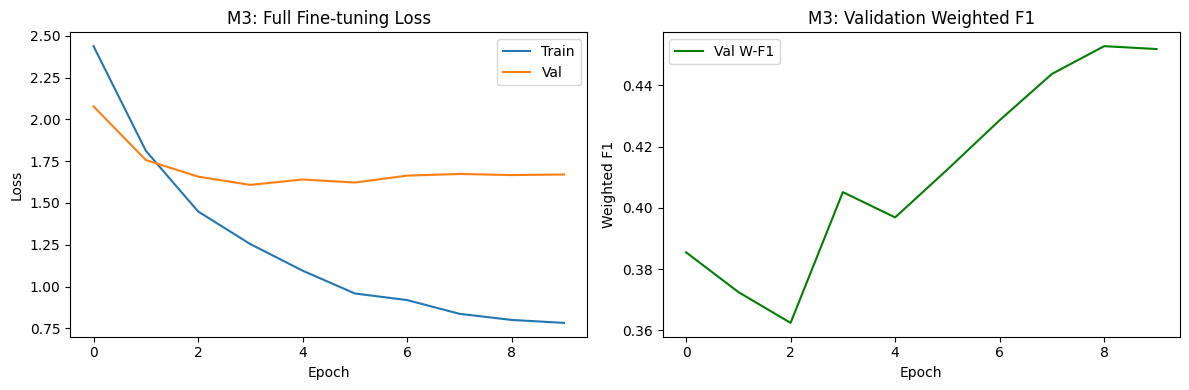

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m3["train_loss"], label="Train")
ax1.plot(history_m3["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M3: Full Fine-tuning Loss")
ax2.plot(history_m3["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M3: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [ ]:
y_pred_m3 = predict_moment(
    model_m3, data_m["X_test"], data_m["mask_test"], device=device,
)
metrics_m3 = evaluate(y_test, y_pred_m3, class_names, "MOMENT Full-FT (M3)")

=== MOMENT Full-FT (M3) ===
Accuracy:    0.4692
Weighted F1: 0.4876
Macro F1:    0.3867
              precision    recall  f1-score   support

          15       0.35      0.60      0.44       124
          16       0.84      0.86      0.85       270
          42       0.47      0.29      0.36       382
          52       0.09      0.21      0.12        63
          53       0.33      0.14      0.20         7
           6       0.23      0.26      0.24        35
          62       0.16      0.25      0.20       153
          64       0.10      0.21      0.13        24
          65       0.71      0.69      0.70       313
          67       0.11      0.32      0.17        68
          88       0.77      0.83      0.80       121
          90       0.69      0.34      0.45       777
          92       0.41      0.61      0.49        77
          95       0.18      0.46      0.26        52

    accuracy                           0.47      2466
   macro avg       0.39      0.43      0.39   

## Summary

In [ ]:
# Full results: all models
all_fm_results = {
    "MOMENT ZS + LogReg (M1)": metrics_m1_lr,
    "MOMENT ZS + RF (M1)":     metrics_m1_rf,
    "MOMENT Head-FT (M2)":     metrics_m2,
    "MOMENT Full-FT (M3)":     metrics_m3,
    "TiReX ZS + LogReg (M4)":  metrics_m4_lr,
    "TiReX ZS + RF (M4)":      metrics_m4_rf,
    "TiReX Head-FT (M5)":      metrics_m5,
    "Chronos-2 ZS + LogReg (M7)": metrics_m7_lr,
    "Chronos-2 ZS + RF (M7)":     metrics_m7_rf,
    "Chronos-2 ZS + XGBoost (M7)": metrics_m7_xgb,
    "Chronos-2 ZS + Ensemble (M7)": metrics_m7_ens,
    "Chronos-2 Head-FT (M8)":     metrics_m8,
    "Chronos-2 LP-FT LoRA (M9)":  metrics_m9,
    "AdaPTS-PCA + MOMENT + LogReg (M10a)":    metrics_m10a_lr,
    "AdaPTS-PCA + MOMENT + XGB (M10a)":       metrics_m10a_xgb,
    "AdaPTS-PCA + MOMENT + Ensemble (M10a)":  metrics_m10a_ens,
    "AdaPTS-PCA + TiReX + LogReg (M10b)":     metrics_m10b_lr,
    "AdaPTS-PCA + TiReX + XGB (M10b)":        metrics_m10b_xgb,
    "AdaPTS-PCA + TiReX + Ensemble (M10b)":   metrics_m10b_ens,
    "AdaPTS-LAE + MOMENT + LogReg (M10c)":    metrics_m10c_lr,
    "AdaPTS-LAE + MOMENT + XGB (M10c)":       metrics_m10c_xgb,
    "AdaPTS-LAE + MOMENT + Ensemble (M10c)":  metrics_m10c_ens,
    "AdaPTS-LAE + TiReX + LogReg (M10d)":     metrics_m10d_lr,
    "AdaPTS-LAE + TiReX + XGB (M10d)":        metrics_m10d_xgb,
    "AdaPTS-LAE + TiReX + Ensemble (M10d)":   metrics_m10d_ens,
}
results_table(all_fm_results)

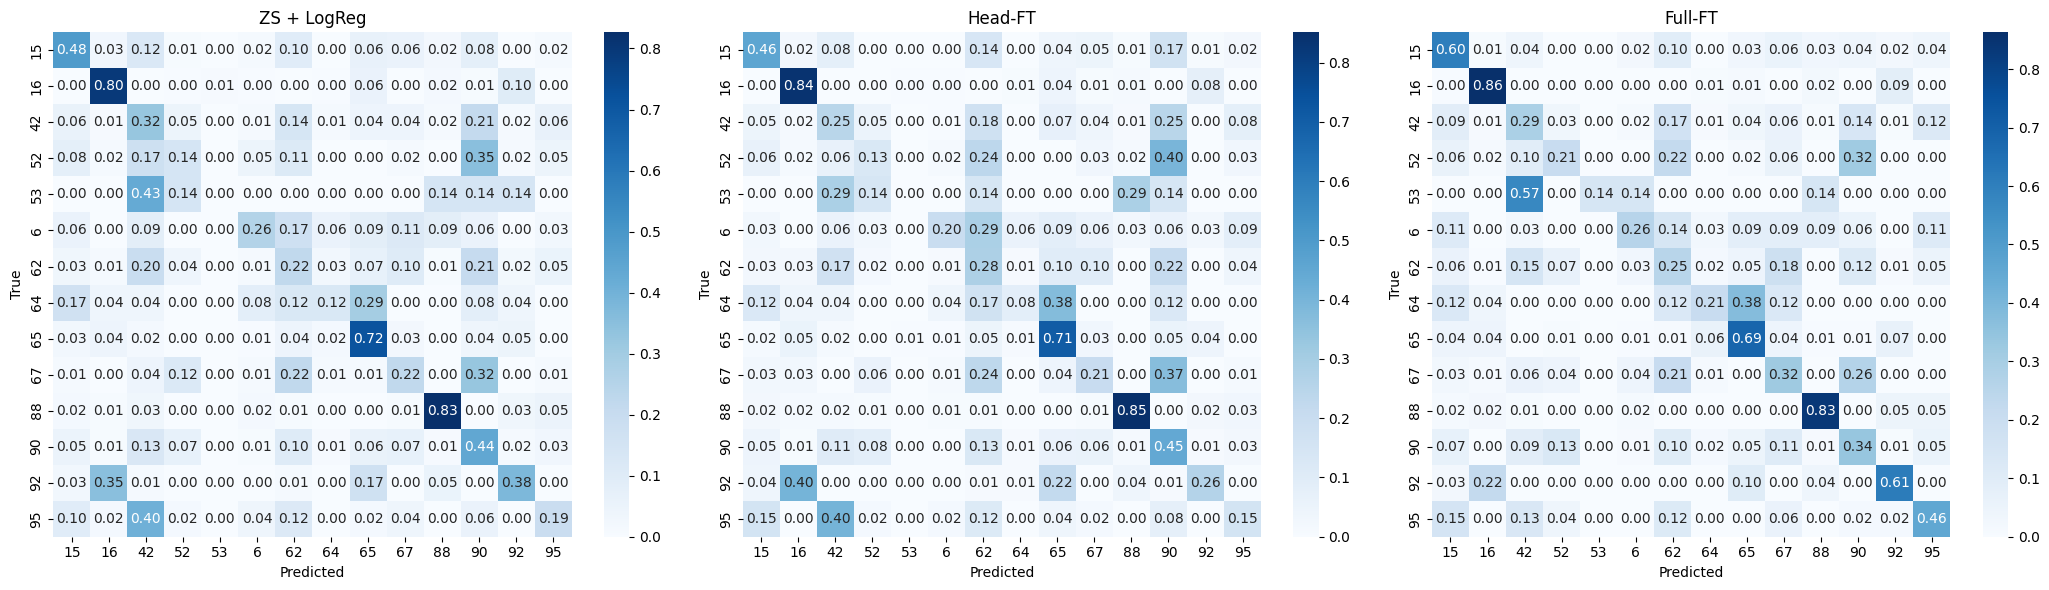

In [ ]:
# Confusion matrices: best M1 vs M2 vs M3
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (name, preds) in zip(axes, [
    ("ZS + LogReg", y_pred_m1_lr),
    ("Head-FT", y_pred_m2),
    ("Full-FT", y_pred_m3),
]):
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=class_names,
                yticklabels=class_names, cmap="Blues", ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("figures/moment_confusion_matrices.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# Save embeddings for analysis notebook
np.savez(
    "moment_embeddings.npz",
    emb_train=emb_train, emb_test=emb_test,
    y_train=y_train, y_test=y_test,
)

## M4: TiReX Zero-shot Embeddings + Classifier

TiReX is an xLSTM-based forecasting FM (NX-AI/TiRex, NeurIPS 2025 workshop).
It is **univariate**: each channel is treated as an independent time series.

Architecture: patch_size=32, hidden_dim=512, 12 layers.
For LSST (36 timesteps × 6 channels): 2 patches/channel → 6 × 512 = 3072-dim embedding.

No fine-tuning needed — we use it purely as a frozen feature extractor.

In [8]:
# Extract TiReX embeddings — uses raw channels-first data (no MOMENT padding needed)
# TiReX handles short series natively (patch_size=32, 36 timesteps -> 2 patches)
X_train_cf = data_sk["X_train"]  # (2459, 6, 36) — raw, no padding
X_test_cf  = data_sk["X_test"]   # (2466, 6, 36)

tirex_emb_train = extract_tirex_embeddings(X_train_cf, device=device)
tirex_emb_test  = extract_tirex_embeddings(X_test_cf,  device=device)
print(f"TiReX embeddings — train: {tirex_emb_train.shape}, test: {tirex_emb_test.shape}")

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 19.53 GiB of which 2.00 MiB is free. Including non-PyTorch memory, this process has 19.38 GiB memory in use. Of the allocated memory 18.99 GiB is allocated by PyTorch, and 201.22 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [35]:
# Logistic Regression on TiReX embeddings
lr_tirex = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=SEED, C=1.0,
)
lr_tirex.fit(tirex_emb_train, y_train)
y_pred_m4_lr = lr_tirex.predict(tirex_emb_test)
metrics_m4_lr = evaluate(y_test, y_pred_m4_lr, class_names, "TiReX ZS + LogReg (M4)")

# Random Forest on TiReX embeddings
rf_tirex = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=SEED,
)
rf_tirex.fit(tirex_emb_train, y_train)
y_pred_m4_rf = rf_tirex.predict(tirex_emb_test)
metrics_m4_rf = evaluate(y_test, y_pred_m4_rf, class_names, "TiReX ZS + RF (M4)")

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/

=== TiReX ZS + LogReg (M4) ===
Accuracy:    0.5580
Weighted F1: 0.5464
Macro F1:    0.3788
              precision    recall  f1-score   support

          15       0.38      0.27      0.32       124
          16       0.88      0.87      0.87       270
          42       0.39      0.43      0.41       382
          52       0.05      0.03      0.04        63
          53       0.00      0.00      0.00         7
           6       0.26      0.29      0.27        35
          62       0.19      0.16      0.17       153
          64       0.10      0.04      0.06        24
          65       0.69      0.76      0.72       313
          67       0.10      0.06      0.07        68
          88       0.90      0.80      0.85       121
          90       0.58      0.66      0.62       777
          92       0.77      0.60      0.67        77
          95       0.29      0.19      0.23        52

    accuracy                           0.56      2466
   macro avg       0.40      0.37      0.38

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

## M5: TiReX Pre-computed Features + MLP Head

Same approach as M2 (MOMENT): pre-compute frozen encoder features, train a small MLP head on top.
No gradient checkpointing issues here — TiReX works cleanly.

In [10]:
# Reuse tirex_emb_train already extracted in M4 — no need to re-run encoder
feats_tr_t, feats_val_t, y_tr_t5, y_val_t5 = stratified_train_val_split(
    tirex_emb_train, y_train
)
print(f"Train: {feats_tr_t.shape}, Val: {feats_val_t.shape}")

head_m5, history_m5 = train_classification_head(
    feats_tr_t, y_tr_t5, feats_val_t, y_val_t5,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=100, lr=1e-3, batch_size=128, patience=15,
    device=device,
)

Train: (1967, 3072), Val: (492, 3072)
Head trainable params: 790,286 (input_dim=3072)
Epoch 10/100 — train_loss=1.2781  val_loss=1.8306  val_wf1=0.2955
Epoch 20/100 — train_loss=0.8594  val_loss=2.1403  val_wf1=0.3552
Epoch 30/100 — train_loss=0.6567  val_loss=2.4032  val_wf1=0.4095
Epoch 40/100 — train_loss=0.5494  val_loss=2.5179  val_wf1=0.4324
Epoch 50/100 — train_loss=0.4936  val_loss=3.0765  val_wf1=0.4592
Epoch 60/100 — train_loss=0.4423  val_loss=2.9711  val_wf1=0.4789
Epoch 70/100 — train_loss=0.3788  val_loss=3.0615  val_wf1=0.4720
Early stopping at epoch 76


In [11]:
# Evaluate M5 on test set
tirex_test_t = torch.tensor(tirex_emb_test, dtype=torch.float32, device=device)
head_m5.eval()
with torch.no_grad():
    y_pred_m5 = head_m5(tirex_test_t).argmax(1).cpu().numpy()
metrics_m5 = evaluate(y_test, y_pred_m5, class_names, "TiReX Head-FT (M5)")

=== TiReX Head-FT (M5) ===
Accuracy:    0.5373
Weighted F1: 0.5262
Macro F1:    0.3968
              precision    recall  f1-score   support

          15       0.48      0.35      0.41       124
          16       0.78      0.89      0.83       270
          42       0.37      0.28      0.32       382
          52       0.05      0.05      0.05        63
          53       0.40      0.29      0.33         7
           6       0.38      0.17      0.24        35
          62       0.19      0.32      0.24       153
          64       0.22      0.08      0.12        24
          65       0.71      0.73      0.72       313
          67       0.00      0.00      0.00        68
          88       0.85      0.89      0.87       121
          90       0.57      0.62      0.59       777
          92       0.59      0.62      0.60        77
          95       0.27      0.21      0.24        52

    accuracy                           0.54      2466
   macro avg       0.42      0.39      0.40    

## M6: TiReX Full Fine-tuning — Not Feasible

TiReX's sLSTM processes all 2048 context tokens **sequentially** (token-by-token recurrence).
Backprop-through-time requires storing all intermediate sLSTM states:
- 64 patches × 12 layers × (batch × 6 channels) intermediate states per backward pass
- At batch_size=8: 48 series × 64 steps × 12 layers ≈ 8-10 GB for activations alone

This is memory-intractable on a 20 GB GPU without gradient checkpointing,
which TiReX does not support natively.

**M5 (frozen encoder + MLP head) is the practical TiReX fine-tuning strategy.**
M4 zero-shot already outperforms all MOMENT variants — M5 head-only is the meaningful comparison.

In [17]:
# Release CUDA-reserved memory from M1-M5 model loading / embedding extraction.
# PyTorch's allocator holds onto GPU memory even after tensors/models go out of scope.
# empty_cache() returns it to the OS so M6 can use it.
import gc
gc.collect()
torch.cuda.empty_cache()

free  = torch.cuda.mem_get_info()[0] / 1024**3
total = torch.cuda.mem_get_info()[1] / 1024**3
print(f"GPU memory free: {free:.1f} / {total:.1f} GB")

GPU memory free: 0.0 / 19.5 GB


In [18]:
import importlib
import src.tirex_pipeline
importlib.reload(src.tirex_pipeline)
from src.tirex_pipeline import load_tirex_for_classification, finetune_tirex, predict_tirex

X_tr_m6, X_val_m6, y_tr_m6, y_val_m6 = stratified_train_val_split(
    data_sk["X_train"], y_train
)
print(f"Train: {X_tr_m6.shape}, Val: {X_val_m6.shape}")

model_m6 = load_tirex_for_classification(
    n_channels=6, n_classes=n_classes, device=device,
)
model_m6, history_m6 = finetune_tirex(
    model_m6, X_tr_m6, y_tr_m6, X_val_m6, y_val_m6,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=50, lr=1e-4, batch_size=8, patience=10,
    device=device,
)

Train: (1967, 6, 36), Val: (492, 6, 36)


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 MiB. GPU 0 has a total capacity of 19.53 GiB of which 2.00 MiB is free. Including non-PyTorch memory, this process has 19.38 GiB memory in use. Of the allocated memory 19.05 GiB is allocated by PyTorch, and 134.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

NameError: name 'history_m6' is not defined

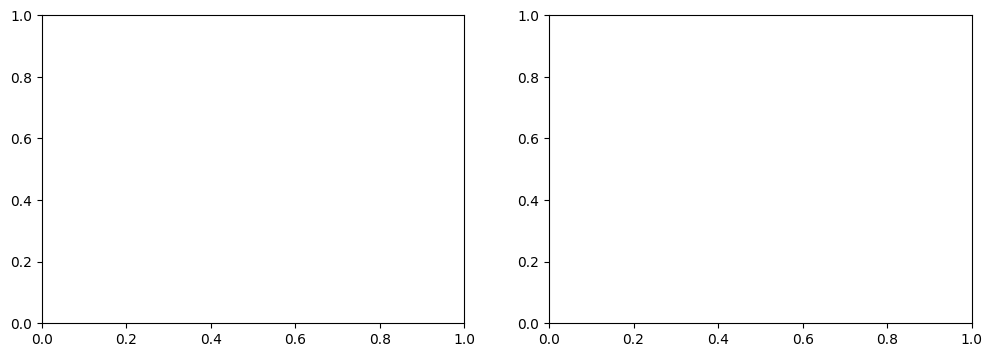

In [19]:
# Plot M6 training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m6["train_loss"], label="Train")
ax1.plot(history_m6["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M6: TiReX Full Fine-tuning Loss")
ax2.plot(history_m6["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M6: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [20]:
y_pred_m6 = predict_tirex(model_m6, data_sk["X_test"], device=device)
metrics_m6 = evaluate(y_test, y_pred_m6, class_names, "TiReX Full-FT (M6)")

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 19.53 GiB of which 2.00 MiB is free. Including non-PyTorch memory, this process has 19.38 GiB memory in use. Of the allocated memory 19.05 GiB is allocated by PyTorch, and 134.64 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## M7: Chronos-2 Zero-shot Embeddings + Classifier

Chronos-2 (Amazon, 2025) is a patch-based forecasting FM with **native multivariate** support.
Unlike MOMENT and TiReX, it processes all 6 channels jointly via alternating
time-attention and group-attention layers.

Key advantages for LSST:
- **No RevIN**: tokenizes via quantile binning — amplitude information is preserved
- **Cross-channel attention**: captures inter-band correlations (e.g., band g peaks before band r)
- **Flexible length**: no forced 512 padding — 36 timesteps → 5 tokens naturally

Architecture: d_model=768, 12 layers, patch_size=16.
Output: (6 variates, 5 tokens, 768) → mean-pool tokens → flatten channels → 4608-dim embedding.

In [6]:
# Release GPU memory from previous models before loading Chronos-2
import gc
gc.collect()
torch.cuda.empty_cache()

# Extract Chronos-2 embeddings — uses raw channels-first data (no padding needed)
# Chronos-2 processes all 6 channels jointly via cross-variate attention
X_train_cf = data_sk["X_train"]  # (2459, 6, 36)
X_test_cf  = data_sk["X_test"]   # (2466, 6, 36)

chronos_emb_train = extract_chronos_embeddings(X_train_cf, device=device, batch_size=64)
chronos_emb_test  = extract_chronos_embeddings(X_test_cf,  device=device, batch_size=64)
print(f"Chronos-2 embeddings — train: {chronos_emb_train.shape}, test: {chronos_emb_test.shape}")

  Embedded 64/2459 samples
  Embedded 384/2459 samples
  Embedded 704/2459 samples
  Embedded 1024/2459 samples
  Embedded 1344/2459 samples
  Embedded 1664/2459 samples
  Embedded 1984/2459 samples
  Embedded 2304/2459 samples
Chronos-2 embeddings: (2459, 4608)
  Embedded 64/2466 samples
  Embedded 384/2466 samples
  Embedded 704/2466 samples
  Embedded 1024/2466 samples
  Embedded 1344/2466 samples
  Embedded 1664/2466 samples
  Embedded 1984/2466 samples
  Embedded 2304/2466 samples
Chronos-2 embeddings: (2466, 4608)
Chronos-2 embeddings — train: (2459, 4608), test: (2466, 4608)


In [8]:
# Logistic Regression on Chronos-2 embeddings
lr_chronos = LogisticRegression(
    max_iter=2000, class_weight="balanced", random_state=SEED, C=1.0,
)
lr_chronos.fit(chronos_emb_train, y_train)
y_pred_m7_lr = lr_chronos.predict(chronos_emb_test)
metrics_m7_lr = evaluate(y_test, y_pred_m7_lr, class_names, "Chronos-2 ZS + LogReg (M7)")

# Random Forest on Chronos-2 embeddings
rf_chronos = RandomForestClassifier(
    n_estimators=500, class_weight="balanced", random_state=SEED,
)
rf_chronos.fit(chronos_emb_train, y_train)
y_pred_m7_rf = rf_chronos.predict(chronos_emb_test)
metrics_m7_rf = evaluate(y_test, y_pred_m7_rf, class_names, "Chronos-2 ZS + RF (M7)")

=== Chronos-2 ZS + LogReg (M7) ===
Accuracy:    0.5998
Weighted F1: 0.5984
Macro F1:    0.4605
              precision    recall  f1-score   support

          15       0.53      0.48      0.50       124
          16       0.92      0.92      0.92       270
          42       0.47      0.46      0.46       382
          52       0.09      0.08      0.08        63
          53       0.50      0.29      0.36         7
           6       0.35      0.26      0.30        35
          62       0.23      0.27      0.24       153
          64       0.08      0.04      0.06        24
          65       0.72      0.80      0.76       313
          67       0.12      0.15      0.14        68
          88       0.91      0.97      0.94       121
          90       0.65      0.63      0.64       777
          92       0.80      0.74      0.77        77
          95       0.29      0.27      0.28        52

    accuracy                           0.60      2466
   macro avg       0.48      0.45      

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [7]:
# XGBoost on Chronos-2 embeddings
from xgboost import XGBClassifier

# Compute sample weights from class weights (XGBoost uses per-sample weights)
cw = data_sk["class_weights"]
sample_weights = np.array([cw[y] for y in y_train])

xgb_chronos = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
)
xgb_chronos.fit(chronos_emb_train, y_train, sample_weight=sample_weights)
y_pred_m7_xgb = xgb_chronos.predict(chronos_emb_test)
metrics_m7_xgb = evaluate(y_test, y_pred_m7_xgb, class_names, "Chronos-2 ZS + XGBoost (M7)")

=== Chronos-2 ZS + XGBoost (M7) ===
Accuracy:    0.6338
Weighted F1: 0.5874
Macro F1:    0.4058
              precision    recall  f1-score   support

          15       0.52      0.39      0.44       124
          16       0.88      0.93      0.90       270
          42       0.52      0.37      0.43       382
          52       0.00      0.00      0.00        63
          53       1.00      0.14      0.25         7
           6       0.57      0.11      0.19        35
          62       0.25      0.10      0.15       153
          64       0.00      0.00      0.00        24
          65       0.69      0.86      0.77       313
          67       0.11      0.01      0.03        68
          88       0.86      0.96      0.91       121
          90       0.58      0.84      0.69       777
          92       0.75      0.73      0.74        77
          95       0.50      0.12      0.19        52

    accuracy                           0.63      2466
   macro avg       0.52      0.40     

/Data/jawad_chemaou/tsX/DL-for-TS/.venv/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [15:40:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [11]:
# Ensemble: soft-vote LogReg + RF + XGBoost on Chronos-2 embeddings
# Each classifier outputs probability vectors; we average them and take argmax.
proba_lr  = lr_chronos.predict_proba(chronos_emb_test)
proba_rf  = rf_chronos.predict_proba(chronos_emb_test)
proba_xgb = xgb_chronos.predict_proba(chronos_emb_test)

# Equal-weight soft voting
proba_ens = (proba_lr + proba_rf + proba_xgb) / 3
y_pred_m7_ens = proba_ens.argmax(axis=1)
metrics_m7_ens = evaluate(y_test, y_pred_m7_ens, class_names, "Chronos-2 ZS + Ensemble (M7)")

=== Chronos-2 ZS + Ensemble (M7) ===
Accuracy:    0.6513
Weighted F1: 0.6167
Macro F1:    0.4488
              precision    recall  f1-score   support

          15       0.60      0.44      0.50       124
          16       0.90      0.95      0.93       270
          42       0.55      0.42      0.48       382
          52       0.00      0.00      0.00        63
          53       1.00      0.14      0.25         7
           6       0.53      0.23      0.32        35
          62       0.26      0.16      0.20       153
          64       0.25      0.04      0.07        24
          65       0.72      0.86      0.78       313
          67       0.15      0.06      0.08        68
          88       0.89      0.97      0.92       121
          90       0.61      0.83      0.70       777
          92       0.84      0.74      0.79        77
          95       0.40      0.19      0.26        52

    accuracy                           0.65      2466
   macro avg       0.55      0.43    

## M8: Chronos-2 Pre-computed Features + MLP Head

Same approach as M2/M5: pre-compute frozen encoder features, train a small MLP head.
The 4608-dim Chronos-2 embeddings capture cross-channel patterns that TiReX misses.

In [5]:
# Reuse chronos_emb_train already extracted in M7
feats_tr_c, feats_val_c, y_tr_c, y_val_c = stratified_train_val_split(
    chronos_emb_train, y_train
)
print(f"Train: {feats_tr_c.shape}, Val: {feats_val_c.shape}")

head_m8, history_m8 = train_classification_head(
    feats_tr_c, y_tr_c, feats_val_c, y_val_c,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=100, lr=1e-3, batch_size=128, patience=15,
    device=device,
)

Train: (1967, 4608), Val: (492, 4608)
Head trainable params: 1,183,502 (input_dim=4608)
Epoch 10/100 — train_loss=0.8500  val_loss=1.6759  val_wf1=0.3657
Epoch 20/100 — train_loss=0.5345  val_loss=1.9768  val_wf1=0.4648
Epoch 30/100 — train_loss=0.3695  val_loss=2.1188  val_wf1=0.5295
Epoch 40/100 — train_loss=0.2536  val_loss=2.3044  val_wf1=0.5527
Epoch 50/100 — train_loss=0.1820  val_loss=2.3617  val_wf1=0.5894
Epoch 60/100 — train_loss=0.1453  val_loss=2.5523  val_wf1=0.5796
Early stopping at epoch 65


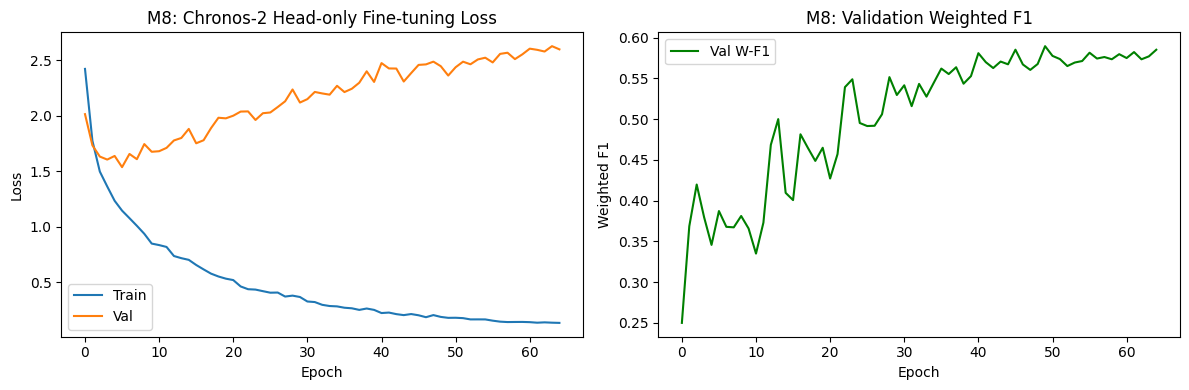

In [6]:
# Plot M8 training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m8["train_loss"], label="Train")
ax1.plot(history_m8["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M8: Chronos-2 Head-only Fine-tuning Loss")
ax2.plot(history_m8["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M8: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [7]:
# Evaluate M8 on test set
chronos_test_t = torch.tensor(chronos_emb_test, dtype=torch.float32, device=device)
head_m8.eval()
with torch.no_grad():
    y_pred_m8 = head_m8(chronos_test_t).argmax(1).cpu().numpy()
metrics_m8 = evaluate(y_test, y_pred_m8, class_names, "Chronos-2 Head-FT (M8)")

=== Chronos-2 Head-FT (M8) ===
Accuracy:    0.5766
Weighted F1: 0.5765
Macro F1:    0.4632
              precision    recall  f1-score   support

          15       0.51      0.48      0.49       124
          16       0.90      0.92      0.91       270
          42       0.45      0.36      0.40       382
          52       0.08      0.16      0.11        63
          53       0.75      0.43      0.55         7
           6       0.41      0.20      0.27        35
          62       0.28      0.25      0.27       153
          64       0.00      0.00      0.00        24
          65       0.71      0.85      0.77       313
          67       0.18      0.25      0.21        68
          88       0.90      0.96      0.93       121
          90       0.61      0.58      0.60       777
          92       0.79      0.71      0.75        77
          95       0.22      0.27      0.24        52

    accuracy                           0.58      2466
   macro avg       0.48      0.46      0.46

## M8b: Chronos-2 Head-FT — Lighter Head (anti-overfitting)

M8 overfits badly (1.18M params on 1967 samples). Try:
- **64-dim hidden** instead of 256 (reduces params ~7x)
- **0.5 dropout** instead of 0.3
- **Stronger weight decay** (1e-2 instead of 1e-4)

In [ ]:
# Reload to pick up the new hidden_dim/dropout/weight_decay params
import importlib
import src.moment_pipeline
importlib.reload(src.moment_pipeline)
from src.moment_pipeline import train_classification_head

# Lighter head: 64-dim hidden, 0.5 dropout, strong weight decay
feats_tr_c, feats_val_c, y_tr_c, y_val_c = stratified_train_val_split(
    chronos_emb_train, y_train
)

head_m8b, history_m8b = train_classification_head(
    feats_tr_c, y_tr_c, feats_val_c, y_val_c,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=200, lr=5e-4, batch_size=128, patience=20,
    hidden_dim=64, dropout=0.5, weight_decay=1e-2,
    device=device,
)

In [ ]:
# Plot M8b training curves — compare with M8
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m8b["train_loss"], label="Train")
ax1.plot(history_m8b["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M8b: Light Head (64-dim, dropout=0.5, wd=1e-2)")
ax2.plot(history_m8b["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M8b: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [ ]:
# Evaluate M8b on test set
chronos_test_t = torch.tensor(chronos_emb_test, dtype=torch.float32, device=device)
head_m8b.eval()
with torch.no_grad():
    y_pred_m8b = head_m8b(chronos_test_t).argmax(1).cpu().numpy()
metrics_m8b = evaluate(y_test, y_pred_m8b, class_names, "Chronos-2 Light Head (M8b)")

## M8c: Chronos-2 Head-FT — Minimal Head

No hidden layer at all — just a linear projection (4608 → 14) with dropout.
This is essentially a regularized logistic regression trained with SGD + class weights.
Only **~64K params**.

In [ ]:
# Reload to pick up hidden_dim=0 support
import importlib
import src.moment_pipeline
importlib.reload(src.moment_pipeline)
from src.moment_pipeline import train_classification_head

feats_tr_c, feats_val_c, y_tr_c, y_val_c = stratified_train_val_split(
    chronos_emb_train, y_train
)

# Linear-only head: hidden_dim=0 → just Dropout + Linear(4608, 14) = ~64K params
head_m8c, history_m8c = train_classification_head(
    feats_tr_c, y_tr_c, feats_val_c, y_val_c,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    epochs=200, lr=5e-4, batch_size=128, patience=20,
    hidden_dim=0, dropout=0.3, weight_decay=1e-2,
    device=device,
)

In [ ]:
# Plot M8c training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_m8c["train_loss"], label="Train")
ax1.plot(history_m8c["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M8c: Linear Head (no hidden, dropout=0.3, wd=1e-2)")
ax2.plot(history_m8c["val_wf1"], label="Val W-F1", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M8c: Validation Weighted F1")
plt.tight_layout(); plt.show()

In [ ]:
# Evaluate M8c on test set
chronos_test_t = torch.tensor(chronos_emb_test, dtype=torch.float32, device=device)
head_m8c.eval()
with torch.no_grad():
    y_pred_m8c = head_m8c(chronos_test_t).argmax(1).cpu().numpy()
metrics_m8c = evaluate(y_test, y_pred_m8c, class_names, "Chronos-2 Linear Head (M8c)")

## M9: Chronos-2 LP-FT with LoRA

**LP-FT** (Linear Probing then Fine-Tuning) with **LoRA** (Low-Rank Adaptation):

**Stage 1 — Linear Probing (LP):** Freeze the entire backbone (including LoRA adapters).
Train only the classification head. This stabilizes the head weights so that when we
later unfreeze the backbone, gradients are controlled and don't cause catastrophic
feature distortion (NTK theory).

**Stage 2 — Fine-Tuning (FT):** Unfreeze LoRA adapters (rank-4 on q/v of all 48 attention
matrices). Fine-tune LoRA + head jointly with a lower learning rate. Only 0.3% of
parameters are updated — the rest of the 120M backbone stays frozen.

This is the recommended approach from the literature for adapting foundation models
in data-scarce regimes (2459 samples, 14 classes).

In [18]:
# Release GPU memory from previous models
import gc
gc.collect()
torch.cuda.empty_cache()

import importlib
import src.chronos_pipeline
importlib.reload(src.chronos_pipeline)
from src.chronos_pipeline import (
    load_chronos_for_lora, finetune_chronos_lpft, predict_chronos,
)

# Load Chronos-2 with LoRA adapters (rank 4, targeting q/v in all attention layers)
model_m9 = load_chronos_for_lora(
    n_channels=6, n_classes=n_classes, lora_rank=4, device=device,
)

trainable params: 294,912 || all params: 119,772,576 || trainable%: 0.2462
Total: 119,837,102 | Trainable: 359,438 (0.30%)


In [19]:
# LP-FT training
# Stage 1 (LP): 30 epochs, lr=1e-3, head only (~64K params)
# Stage 2 (FT): 70 epochs, lr=1e-4, LoRA + head (~360K params)
X_tr_m9, X_val_m9, y_tr_m9, y_val_m9 = stratified_train_val_split(
    data_sk["X_train"], y_train
)
print(f"Train: {X_tr_m9.shape}, Val: {X_val_m9.shape}")

model_m9, history_m9 = finetune_chronos_lpft(
    model_m9, X_tr_m9, y_tr_m9, X_val_m9, y_val_m9,
    class_weights=data_sk["class_weights"],
    n_classes=n_classes,
    lp_epochs=30, ft_epochs=70,
    lp_lr=1e-3, ft_lr=1e-4,
    batch_size=16, patience=15,
    weight_decay=1e-2, device=device,
)

Train: (1967, 6, 36), Val: (492, 6, 36)

Stage: LP | LR: 0.001 | Trainable: 64,526
  [LP] Epoch 5/30 — train_loss=1.0339  val_loss=1.8055  val_wf1=0.4023
  [LP] Epoch 10/30 — train_loss=0.7037  val_loss=2.0204  val_wf1=0.4513
  [LP] Epoch 15/30 — train_loss=0.5666  val_loss=2.2065  val_wf1=0.5719
  [LP] Epoch 20/30 — train_loss=0.4984  val_loss=2.2177  val_wf1=0.5420
  [LP] Epoch 25/30 — train_loss=0.4397  val_loss=2.1892  val_wf1=0.5525
  [LP] Epoch 30/30 — train_loss=0.4325  val_loss=2.1833  val_wf1=0.5601

Stage: FT | LR: 0.0001 | Trainable: 359,438
  [FT] Epoch 5/70 — train_loss=0.3447  val_loss=3.0207  val_wf1=0.5673
  [FT] Epoch 10/70 — train_loss=0.2888  val_loss=3.2150  val_wf1=0.5733
  [FT] Epoch 15/70 — train_loss=0.2499  val_loss=3.5148  val_wf1=0.5525
  [FT] Epoch 20/70 — train_loss=0.2267  val_loss=3.5362  val_wf1=0.5630
  [FT] Epoch 25/70 — train_loss=0.1818  val_loss=3.4950  val_wf1=0.5550
  [FT] Epoch 30/70 — train_loss=0.1602  val_loss=3.6515  val_wf1=0.5590
  [FT] Epo

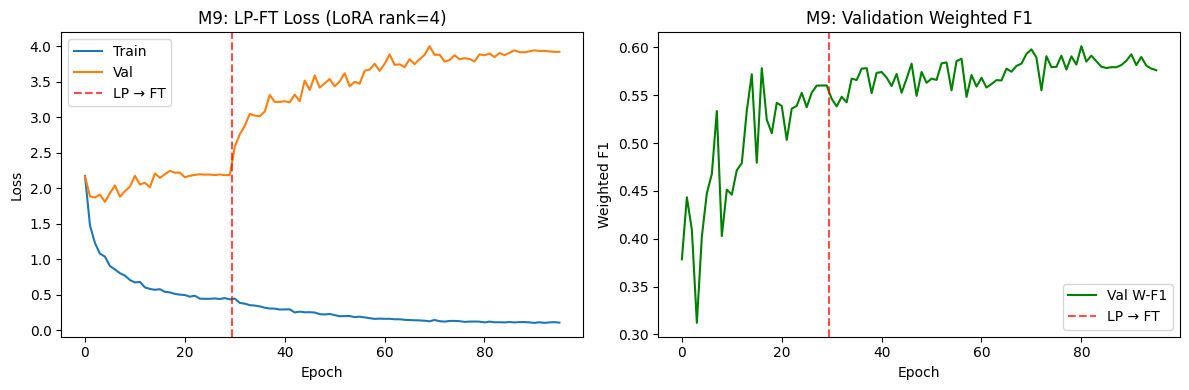

LP stage: 30 epochs | FT stage: 66 epochs
Best val W-F1: 0.6012


In [20]:
# Plot M9 LP-FT training curves with stage boundary
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Find stage boundary
lp_epochs = sum(1 for s in history_m9["stage"] if s == "LP")

ax1.plot(history_m9["train_loss"], label="Train")
ax1.plot(history_m9["val_loss"], label="Val")
ax1.axvline(x=lp_epochs - 0.5, color="red", linestyle="--", alpha=0.7, label="LP → FT")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.set_title("M9: LP-FT Loss (LoRA rank=4)")

ax2.plot(history_m9["val_wf1"], label="Val W-F1", color="green")
ax2.axvline(x=lp_epochs - 0.5, color="red", linestyle="--", alpha=0.7, label="LP → FT")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1"); ax2.legend()
ax2.set_title("M9: Validation Weighted F1")

plt.tight_layout(); plt.show()
print(f"LP stage: {lp_epochs} epochs | FT stage: {len(history_m9['stage']) - lp_epochs} epochs")
print(f"Best val W-F1: {max(history_m9['val_wf1']):.4f}")

In [21]:
# Evaluate M9 on test set
y_pred_m9 = predict_chronos(model_m9, data_sk["X_test"], batch_size=16, device=device)
metrics_m9 = evaluate(y_test, y_pred_m9, class_names, "Chronos-2 LP-FT LoRA (M9)")

=== Chronos-2 LP-FT LoRA (M9) ===
Accuracy:    0.6002
Weighted F1: 0.5946
Macro F1:    0.4775
              precision    recall  f1-score   support

          15       0.51      0.48      0.50       124
          16       0.89      0.89      0.89       270
          42       0.46      0.47      0.47       382
          52       0.06      0.05      0.05        63
          53       1.00      0.57      0.73         7
           6       0.47      0.26      0.33        35
          62       0.21      0.21      0.21       153
          64       0.12      0.08      0.10        24
          65       0.74      0.87      0.80       313
          67       0.14      0.15      0.15        68
          88       0.93      0.92      0.92       121
          90       0.64      0.63      0.63       777
          92       0.69      0.73      0.71        77
          95       0.22      0.17      0.19        52

    accuracy                           0.60      2466
   macro avg       0.51      0.46      0

## M10: AdaPTS-adapted Embeddings (MOMENT & TiReX)

**Problem**: MOMENT and TiReX are univariate FMs — they process each channel independently,
missing cross-channel correlations that EDA identified as highly discriminative for LSST.

**Solution**: [AdaPTS](https://github.com/abenechehab/AdaPTS) (ICML 2025) learns lightweight
adapters that project multivariate inputs into a latent space where univariate FMs can
capture cross-channel structure. We use:

- **PCA adapter**: unsupervised, projects 6 bands → k principal components at each timestep.
  Each component is a linear combination of all 6 bands — the FM now "sees" cross-channel info.
- **LinearAE adapter**: learned linear autoencoder trained on reconstruction objective.
  Can capture different projection directions than PCA.

The adapted (N, k, T) series are then fed to MOMENT/TiReX for embedding extraction,
followed by the same LogReg / XGBoost / Ensemble classifiers.

In [12]:
# Release GPU memory before reloading MOMENT/TiReX
import gc
gc.collect()
torch.cuda.empty_cache()

from adapts.adapters import MultichannelProjector

X_train_cf = data_sk["X_train"]  # (2459, 6, 36)
X_test_cf  = data_sk["X_test"]   # (2466, 6, 36)

# --- PCA adapter: 6 channels → 2 principal components ---
pca_adapter = MultichannelProjector(
    num_channels=6,
    new_num_channels=2,
    patch_window_size=1,
    base_projector="pca",
)
pca_adapter.fit(X_train_cf)

X_train_pca = pca_adapter.transform(X_train_cf)  # (2459, 2, 36)
X_test_pca  = pca_adapter.transform(X_test_cf)    # (2466, 2, 36)
print(f"PCA-adapted — train: {X_train_pca.shape}, test: {X_test_pca.shape}")

# Check reconstruction quality
X_recon = pca_adapter.inverse_transform(X_train_pca)
recon_mse = np.mean((X_train_cf - X_recon) ** 2)
print(f"PCA reconstruction MSE: {recon_mse:.6f}")

# --- LinearAE adapter: 6 channels → 2 latent dims ---
linae_adapter = MultichannelProjector(
    num_channels=6,
    new_num_channels=2,
    patch_window_size=1,
    base_projector="linearAE",
    device=device,
    context_length=36,
    forecast_horizon=0,
)
linae_adapter.fit(X_train_cf)

X_train_lae = linae_adapter.transform(X_train_cf)  # (2459, 2, 36)
X_test_lae  = linae_adapter.transform(X_test_cf)    # (2466, 2, 36)
print(f"LinearAE-adapted — train: {X_train_lae.shape}, test: {X_test_lae.shape}")

X_recon_lae = linae_adapter.inverse_transform(X_train_lae)
recon_mse_lae = np.mean((X_train_cf - X_recon_lae) ** 2)
print(f"LinearAE reconstruction MSE: {recon_mse_lae:.6f}")

PCA-adapted — train: (2459, 2, 36), test: (2466, 2, 36)
PCA reconstruction MSE: 159828.078125


Training Epochs:  10%|▉         | 29/300 [00:00<00:07, 36.11it/s]

LinearAE-adapted — train: (2459, 2, 36), test: (2466, 2, 36)
LinearAE reconstruction MSE: 353760.250000


In [ ]:
# --- M10a: AdaPTS PCA + MOMENT embeddings ---
# Pad adapted series from 36 → 512 for MOMENT
def pad_for_moment(X_cf, target_len=512):
    """(N, C, T) → (N, C, 512) with zero-padding + 2D mask (N, 512)."""
    N, C, T = X_cf.shape
    X_pad = np.zeros((N, C, target_len), dtype=np.float32)
    X_pad[:, :, :T] = X_cf
    # MOMENT expects 2D mask: (N, seq_len) — same mask for all channels
    mask = np.zeros((N, target_len), dtype=np.float32)
    mask[:, :T] = 1.0
    return torch.tensor(X_pad), torch.tensor(mask)

X_train_pca_pad, mask_train_pca = pad_for_moment(X_train_pca)
X_test_pca_pad, mask_test_pca = pad_for_moment(X_test_pca)
print(f"PCA-MOMENT input: {X_train_pca_pad.shape}, mask: {mask_train_pca.shape}")
print(f"Padding: {100*36/512:.0f}% vs 93% original")

# Extract MOMENT embeddings on PCA-adapted data (2 channels instead of 6)
emb_train_pca_m = extract_moment_embeddings(
    X_train_pca_pad, mask_train_pca, model_name=MODEL_NAME, device=device,
)
emb_test_pca_m = extract_moment_embeddings(
    X_test_pca_pad, mask_test_pca, model_name=MODEL_NAME, device=device,
)
print(f"PCA-MOMENT embeddings: train={emb_train_pca_m.shape}, test={emb_test_pca_m.shape}")

# Classifiers on PCA-MOMENT embeddings
from xgboost import XGBClassifier

lr_pca_m = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_pca_m.fit(emb_train_pca_m, y_train)
y_pred_m10a_lr = lr_pca_m.predict(emb_test_pca_m)
metrics_m10a_lr = evaluate(y_test, y_pred_m10a_lr, class_names, "AdaPTS-PCA + MOMENT + LogReg (M10a)")

xgb_pca_m = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    tree_method="hist", device="cuda", eval_metric="mlogloss")
sw = np.array([data_sk["class_weights"][y] for y in y_train])
xgb_pca_m.fit(emb_train_pca_m, y_train, sample_weight=sw)
y_pred_m10a_xgb = xgb_pca_m.predict(emb_test_pca_m)
metrics_m10a_xgb = evaluate(y_test, y_pred_m10a_xgb, class_names, "AdaPTS-PCA + MOMENT + XGB (M10a)")

# Ensemble
proba_lr_m10a  = lr_pca_m.predict_proba(emb_test_pca_m)
proba_xgb_m10a = xgb_pca_m.predict_proba(emb_test_pca_m)
y_pred_m10a_ens = ((proba_lr_m10a + proba_xgb_m10a) / 2).argmax(axis=1)
metrics_m10a_ens = evaluate(y_test, y_pred_m10a_ens, class_names, "AdaPTS-PCA + MOMENT + Ensemble (M10a)")

In [ ]:
# --- M10b: AdaPTS PCA + TiReX embeddings ---
# TiReX handles short series natively, no padding needed
tirex_emb_train_pca = extract_tirex_embeddings(X_train_pca, device=device)
tirex_emb_test_pca  = extract_tirex_embeddings(X_test_pca, device=device)
print(f"PCA-TiReX embeddings: train={tirex_emb_train_pca.shape}, test={tirex_emb_test_pca.shape}")

lr_pca_t = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_pca_t.fit(tirex_emb_train_pca, y_train)
y_pred_m10b_lr = lr_pca_t.predict(tirex_emb_test_pca)
metrics_m10b_lr = evaluate(y_test, y_pred_m10b_lr, class_names, "AdaPTS-PCA + TiReX + LogReg (M10b)")

xgb_pca_t = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    tree_method="hist", device="cuda", eval_metric="mlogloss")
xgb_pca_t.fit(tirex_emb_train_pca, y_train, sample_weight=sw)
y_pred_m10b_xgb = xgb_pca_t.predict(tirex_emb_test_pca)
metrics_m10b_xgb = evaluate(y_test, y_pred_m10b_xgb, class_names, "AdaPTS-PCA + TiReX + XGB (M10b)")

# Ensemble
proba_lr_m10b  = lr_pca_t.predict_proba(tirex_emb_test_pca)
proba_xgb_m10b = xgb_pca_t.predict_proba(tirex_emb_test_pca)
y_pred_m10b_ens = ((proba_lr_m10b + proba_xgb_m10b) / 2).argmax(axis=1)
metrics_m10b_ens = evaluate(y_test, y_pred_m10b_ens, class_names, "AdaPTS-PCA + TiReX + Ensemble (M10b)")

In [ ]:
# --- M10c: AdaPTS LinearAE + MOMENT embeddings ---
X_train_lae_pad, mask_train_lae = pad_for_moment(X_train_lae)
X_test_lae_pad, mask_test_lae = pad_for_moment(X_test_lae)

emb_train_lae_m = extract_moment_embeddings(
    X_train_lae_pad, mask_train_lae, model_name=MODEL_NAME, device=device,
)
emb_test_lae_m = extract_moment_embeddings(
    X_test_lae_pad, mask_test_lae, model_name=MODEL_NAME, device=device,
)
print(f"LinearAE-MOMENT embeddings: train={emb_train_lae_m.shape}, test={emb_test_lae_m.shape}")

lr_lae_m = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_lae_m.fit(emb_train_lae_m, y_train)
y_pred_m10c_lr = lr_lae_m.predict(emb_test_lae_m)
metrics_m10c_lr = evaluate(y_test, y_pred_m10c_lr, class_names, "AdaPTS-LAE + MOMENT + LogReg (M10c)")

xgb_lae_m = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    tree_method="hist", device="cuda", eval_metric="mlogloss")
xgb_lae_m.fit(emb_train_lae_m, y_train, sample_weight=sw)
y_pred_m10c_xgb = xgb_lae_m.predict(emb_test_lae_m)
metrics_m10c_xgb = evaluate(y_test, y_pred_m10c_xgb, class_names, "AdaPTS-LAE + MOMENT + XGB (M10c)")

proba_lr_m10c  = lr_lae_m.predict_proba(emb_test_lae_m)
proba_xgb_m10c = xgb_lae_m.predict_proba(emb_test_lae_m)
y_pred_m10c_ens = ((proba_lr_m10c + proba_xgb_m10c) / 2).argmax(axis=1)
metrics_m10c_ens = evaluate(y_test, y_pred_m10c_ens, class_names, "AdaPTS-LAE + MOMENT + Ensemble (M10c)")

In [ ]:
# --- M10d: AdaPTS LinearAE + TiReX embeddings ---
tirex_emb_train_lae = extract_tirex_embeddings(X_train_lae, device=device)
tirex_emb_test_lae  = extract_tirex_embeddings(X_test_lae, device=device)
print(f"LinearAE-TiReX embeddings: train={tirex_emb_train_lae.shape}, test={tirex_emb_test_lae.shape}")

lr_lae_t = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_lae_t.fit(tirex_emb_train_lae, y_train)
y_pred_m10d_lr = lr_lae_t.predict(tirex_emb_test_lae)
metrics_m10d_lr = evaluate(y_test, y_pred_m10d_lr, class_names, "AdaPTS-LAE + TiReX + LogReg (M10d)")

xgb_lae_t = XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    tree_method="hist", device="cuda", eval_metric="mlogloss")
xgb_lae_t.fit(tirex_emb_train_lae, y_train, sample_weight=sw)
y_pred_m10d_xgb = xgb_lae_t.predict(tirex_emb_test_lae)
metrics_m10d_xgb = evaluate(y_test, y_pred_m10d_xgb, class_names, "AdaPTS-LAE + TiReX + XGB (M10d)")

proba_lr_m10d  = lr_lae_t.predict_proba(tirex_emb_test_lae)
proba_xgb_m10d = xgb_lae_t.predict_proba(tirex_emb_test_lae)
y_pred_m10d_ens = ((proba_lr_m10d + proba_xgb_m10d) / 2).argmax(axis=1)
metrics_m10d_ens = evaluate(y_test, y_pred_m10d_ens, class_names, "AdaPTS-LAE + TiReX + Ensemble (M10d)")